In [55]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats 

In [76]:

df = pd.read_csv("PreTest2.csv")
df = df.drop([0, 1]).reset_index(drop=True)
df = df[(df["DiscNoPers"] == "1") | (df["DiscPers"] == "1")]

df = df.drop(columns=['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress',
       'Duration (in seconds)', 'Finished', 'RecordedDate', 'DiscNoPers', 'DiscPers',
       'RecipientLastName', 'RecipientFirstName', 'RecipientEmail',
       'ExternalReference', 'LocationLatitude', 'LocationLongitude',
       'DistributionChannel', 'UserLanguage', 'Q_RecaptchaScore', '__js_NextPage_MS',
       '__js_Prompt1_Clicked', '__js_Prompt2_Clicked', '__js_Prompt3_Clicked', '__js_Prompt4_Clicked',
       '__js_AllPromptsClicked', 'Gradio', 'PROLIFIC_PID', 'ResponseId', 'Q_RecaptchaStatus', 'Q_RecaptchaError',
       'AC1', 'AC2', 'AC3', 'AC4'])

warmth_columns = ['W_Q1_1', 'W_Q1_2', 'W_Q1_3', 'W_Q1_4']
personalization_columns = ['MC_Personal_1', 'MC_Personal_2']
emotional_trust_columns = ['ET_1', 'ET_2', 'ET_3']
competent_trust_columns = ['CTC_1', 'CTC_2', 'CTI_1', 'CTI_2', 'CTI_3']
digital_literacy_columns = ['DL_1', 'DL_2', 'DL_3', 'DL_4', 'DL_5', 'DL_6', 'DL_7']
for col in [warmth_columns, personalization_columns, emotional_trust_columns, competent_trust_columns, digital_literacy_columns]:
    for c in col:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df["PreDV_Slider_1"] = pd.to_numeric(df["PreDV_Slider_1"], errors='coerce')
df["PostDV_Slider_1"] = pd.to_numeric(df["PostDV_Slider_1"], errors='coerce')
df["Slider_Difference"] = df["PostDV_Slider_1"] - df["PreDV_Slider_1"]
df["DV_Binary_Diff"] = pd.to_numeric(df["PostDV_Binary"], errors='coerce') - pd.to_numeric(df["PreDV_Binary"], errors='coerce')

df["Warmth_Check"] = df[warmth_columns].mean(axis=1)
df["Personalization_Check"] = df[personalization_columns].mean(axis=1)
df["Emotional_Trust"] = df[emotional_trust_columns].mean(axis=1)
df["Competent_Trust"] = df[competent_trust_columns].mean(axis=1)
df["Digital_Literacy"] = df[digital_literacy_columns].mean(axis=1)
df["UF_Q1"] = df["UF_Q1"].astype(int)

df["Personalization"] = pd.to_numeric(df["Personalization"], errors='coerce')
df["Warmth"] = pd.to_numeric(df["Warmth"], errors='coerce')

In [74]:
df = df[20:]

In [58]:
df.columns

Index(['PID', 'Age', 'Education', 'Work', 'Hobbies', 'PreDV_Slider_1',
       'PreDV_Binary', 'PostDV_Slider_1', 'PostDV_Binary', 'MC_Personal_1',
       'MC_Personal_2', 'W_Q1_1', 'W_Q1_2', 'W_Q1_3', 'W_Q1_4', 'CTC_1',
       'CTC_2', 'CTI_1', 'CTI_2', 'CTI_3', 'ET_1', 'ET_2', 'ET_3', 'DL_1',
       'DL_2', 'DL_3', 'DL_4', 'DL_5', 'DL_6', 'DL_7', 'UF_Q1',
       'Personality_1', 'Personality_2', 'Personality_3', 'Personality_4',
       'Personality_5', 'Personality_6', 'Personality_7', 'Personality_8',
       'Personality_9', 'Personality_10', 'ResponseID', 'AC_City', 'AC_Expert',
       'AC_Risk', 'AC_Assistant', 'Warmth', 'Personalization',
       'Slider_Difference', 'DV_Binary_Diff', 'Warmth_Check',
       'Personalization_Check', 'Emotional_Trust', 'Competent_Trust',
       'Digital_Literacy'],
      dtype='object')

In [59]:
def cronbach_alpha(df: pd.DataFrame) -> float:
    """Cronbach's alpha (columns=items). Handles NaNs by pairwise deletion in cov."""
    df = df.astype(float)
    k = df.shape[1]
    if k < 2:
        return np.nan  # undefined for single item
    cov = df.cov()
    var_sum = np.trace(cov)
    total_var = cov.values.sum()
    if total_var == 0:
        return np.nan  # guard against zero-variance edge case
    return (k / (k - 1)) * (1 - var_sum / total_var)

def alpha_if_deleted(df: pd.DataFrame) -> pd.Series:
    """Alpha if each item is dropped. Returns NaN when dropping yields < 2 items."""
    alphas = {}
    for col in df.columns:
        reduced = df.drop(columns=[col])
        if reduced.shape[1] < 2:
            alphas[col] = np.nan  # can't compute alpha on 1 item
        else:
            alphas[col] = cronbach_alpha(reduced)
    return pd.Series(alphas, name="alpha_if_deleted")

def corrected_item_total(df: pd.DataFrame) -> pd.Series:
    """
    Corrected item–total correlation for each item:
    corr(item, total_score_without_item)
    """
    df = df.astype(float)
    citc = {}
    for col in df.columns:
        total_minus = df.drop(columns=[col]).sum(axis=1)
        citc[col] = df[col].corr(total_minus)
    return pd.Series(citc, name="CITC")

def mean_interitem_corr(df: pd.DataFrame) -> pd.Series:
    """Mean correlation of each item with all other items."""
    corr = df.corr()
    mic = (corr.sum(axis=1) - 1) / (corr.shape[1] - 1)
    return mic.rename("mean_interitem_corr")

# ---------- Proper KMO (overall + per-item MSA) ----------
def kmo_msa(df: pd.DataFrame):
    """
    Kaiser–Meyer–Olkin measure.
    Returns overall KMO and a per-item MSA Series.
    """
    X = df.astype(float).dropna(axis=0, how="any")  # KMO needs complete rows
    R = X.corr().values
    invR = np.linalg.pinv(R)

    # Partial correlation matrix (off-diagonals)
    D = np.diag(1 / np.sqrt(np.diag(invR)))
    P = -D @ invR @ D
    np.fill_diagonal(P, 0.0)

    # Correlation and partial-correlation sums of squares (off-diagonal only)
    R2 = R ** 2
    P2 = P ** 2
    np.fill_diagonal(R2, 0.0)
    np.fill_diagonal(P2, 0.0)

    # Per-item MSA (KMO) and overall KMO
    msa_i = R2.sum(axis=0) / (R2.sum(axis=0) + P2.sum(axis=0))
    overall = R2.sum() / (R2.sum() + P2.sum())
    msa = pd.Series(msa_i, index=df.columns, name="MSA")
    return overall, msa

# ---------- One-shot report ----------
def scale_diagnostics(df: pd.DataFrame):
    df = df.copy()
    a = cronbach_alpha(df)
    citc = corrected_item_total(df)
    aid = alpha_if_deleted(df)
    mic = mean_interitem_corr(df)
    kmo_overall, msa = kmo_msa(df)

    out = pd.concat([citc, aid, mic, msa], axis=1)
    out["alpha_current"] = a
    out["kmo_overall"] = kmo_overall

    # Simple flags (tweak thresholds as needed)
    out["flag_low_CITC"] = out["CITC"] < 0.30
    out["flag_alpha_improves_if_dropped"] = out["alpha_if_deleted"] > a + 0.02
    out["flag_low_MSA"] = out["MSA"] < 0.50
    out["flag_low_mean_interitem"] = out["mean_interitem_corr"] < 0.15

    out = out.sort_values(["flag_alpha_improves_if_dropped", "CITC"], ascending=[False, True])
    return a, kmo_overall, out

scales = {
    'Warmth_Check': warmth_columns,
    'Personalization_Check': personalization_columns,
    'Digital_Literacy': digital_literacy_columns,
    "Emotional_Trust": emotional_trust_columns,
    "Competent_Trust": competent_trust_columns
}

for scale, items in scales.items():
    df_scale = df[items]
    alpha, kmo_overall, table = scale_diagnostics(df_scale)
    print(f"\n=== {scale} ===")
    print(f"Alpha: {alpha:.3f} | KMO: {kmo_overall:.3f}")
    display_cols = ["CITC", "alpha_if_deleted", "mean_interitem_corr", "MSA",
                    "flag_low_CITC", "flag_alpha_improves_if_dropped", "flag_low_MSA"]
    print(table[display_cols].round(3))


=== Warmth_Check ===
Alpha: 0.949 | KMO: 0.747
         CITC  alpha_if_deleted  mean_interitem_corr    MSA  flag_low_CITC  \
W_Q1_4  0.824             0.957                0.792  0.785          False   
W_Q1_2  0.839             0.945                0.804  0.932          False   
W_Q1_3  0.924             0.921                0.868  0.684          False   
W_Q1_1  0.952             0.913                0.885  0.670          False   

        flag_alpha_improves_if_dropped  flag_low_MSA  
W_Q1_4                           False         False  
W_Q1_2                           False         False  
W_Q1_3                           False         False  
W_Q1_1                           False         False  

=== Personalization_Check ===
Alpha: 0.992 | KMO: 0.500
                CITC  alpha_if_deleted  mean_interitem_corr  MSA  \
MC_Personal_2  0.986               NaN                0.986  0.5   
MC_Personal_1  0.986               NaN                0.986  0.5   

               flag_low_

In [60]:
df[["Slider_Difference", "Warmth", "Personalization", "Warmth_Check", "Personalization_Check", "Emotional_Trust", "Competent_Trust", "Digital_Literacy", "UF_Q1"]].groupby(["Warmth", "Personalization"]).mean()

Slider_Difference  Warmth_Check  \
Warmth Personalization                                    
0      0                   -100000.000000      4.187500   
       1                   -180000.000000      5.100000   
1      0                   -133333.333333      5.916667   
       1                   -260000.000000      6.150000   

                        Personalization_Check  Emotional_Trust  \
Warmth Personalization                                           
0      0                             2.250000         3.166667   
       1                             6.500000         5.866667   
1      0                             4.166667         4.555556   
       1                             6.600000         5.800000   

                        Competent_Trust  Digital_Literacy  UF_Q1  
Warmth Personalization                                            
0      0                           4.15          2.928571    4.0  
       1                           5.64          3.285714    2.8  
1      0                           4.70          3.238095    2.0  
       1                           6.08          2.228571    2.2

In [61]:
df.groupby(["Warmth", "Personalization"]).count()["PID"]

Warmth  Personalization
0       0                  4
        1                  5
1       0                  6
        1                  5
Name: PID, dtype: int64

In [62]:
prev = (
    df.groupby(["Warmth", "Personalization", "DV_Binary_Diff"])["PID"]
    .count()
    .groupby(level=[0, 1])
    .transform(lambda x: x / x.sum())
    .reset_index()
    .rename(columns={"PID": "Proportion"})
)

prev[prev["DV_Binary_Diff"] == 1]

,Warmth,Personalization,DV_Binary_Diff,Proportion
2,0,1,1,0.6
4,1,0,1,0.5
7,1,1,1,0.2


In [63]:
df[["Slider_Difference", "Warmth", "Personalization"]].groupby(["Warmth", "Personalization"]).mean()

Slider_Difference
Warmth Personalization                   
0      0                   -100000.000000
       1                   -180000.000000
1      0                   -133333.333333
       1                   -260000.000000

In [64]:
df[["Warmth_Check", "Slider_Difference" ,"Warmth"]].groupby(["Warmth"]).mean()

,Warmth_Check,Slider_Difference
Warmth,,
0,4.694444,-144444.444444
1,6.022727,-190909.090909


In [65]:
g1 = df[df["Warmth"] == 0]["Warmth_Check"]
g2 = df[df["Warmth"] == 1]["Warmth_Check"]   

t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
print("Warmth Manipulation")
print("t =", t_stat, "p =", p_val)

g1 = df[df["Warmth"] == 0]["Slider_Difference"]
g2 = df[df["Warmth"] == 1]["Slider_Difference"]   
print("Slider Difference for Warmth")
t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
print("t =", t_stat, "p =", p_val)

Warmth Manipulation
t = -3.934785276261397 p = 0.001228253662839971
Slider Difference for Warmth
t = 0.6469063510796776 p = 0.5259264164823823


In [66]:
df[["Personalization_Check", "Slider_Difference", "Personalization"]].groupby(["Personalization"]).mean()

,Personalization_Check,Slider_Difference
Personalization,,
0,3.40,-120000.0
1,6.55,-220000.0


In [67]:
g1 = df[df["Personalization"] == 0]["Personalization_Check"]
g2 = df[df["Personalization"] == 1]["Personalization_Check"]   

t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
print("Personalization Manipulation")
print("t =", t_stat, "p =", p_val)

g1 = df[df["Personalization"] == 0]["Slider_Difference"]
g2 = df[df["Personalization"] == 1]["Slider_Difference"]   
print("Slider Difference for Personalization")
t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
print("t =", t_stat, "p =", p_val)

Personalization Manipulation
t = -5.115587040529245 p = 0.0004599996560733323
Slider Difference for Personalization
t = 1.4433756729740643 p = 0.16667441136700525


In [68]:
df["Slider_Difference"]

0    -300000
1    -200000
2    -200000
3    -200000
4          0
5    -300000
6          0
7          0
8    -300000
9    -400000
10         0
11   -400000
12   -300000
13   -400000
14   -200000
15   -200000
16   -100000
17         0
18         0
19    100000
Name: Slider_Difference, dtype: int64

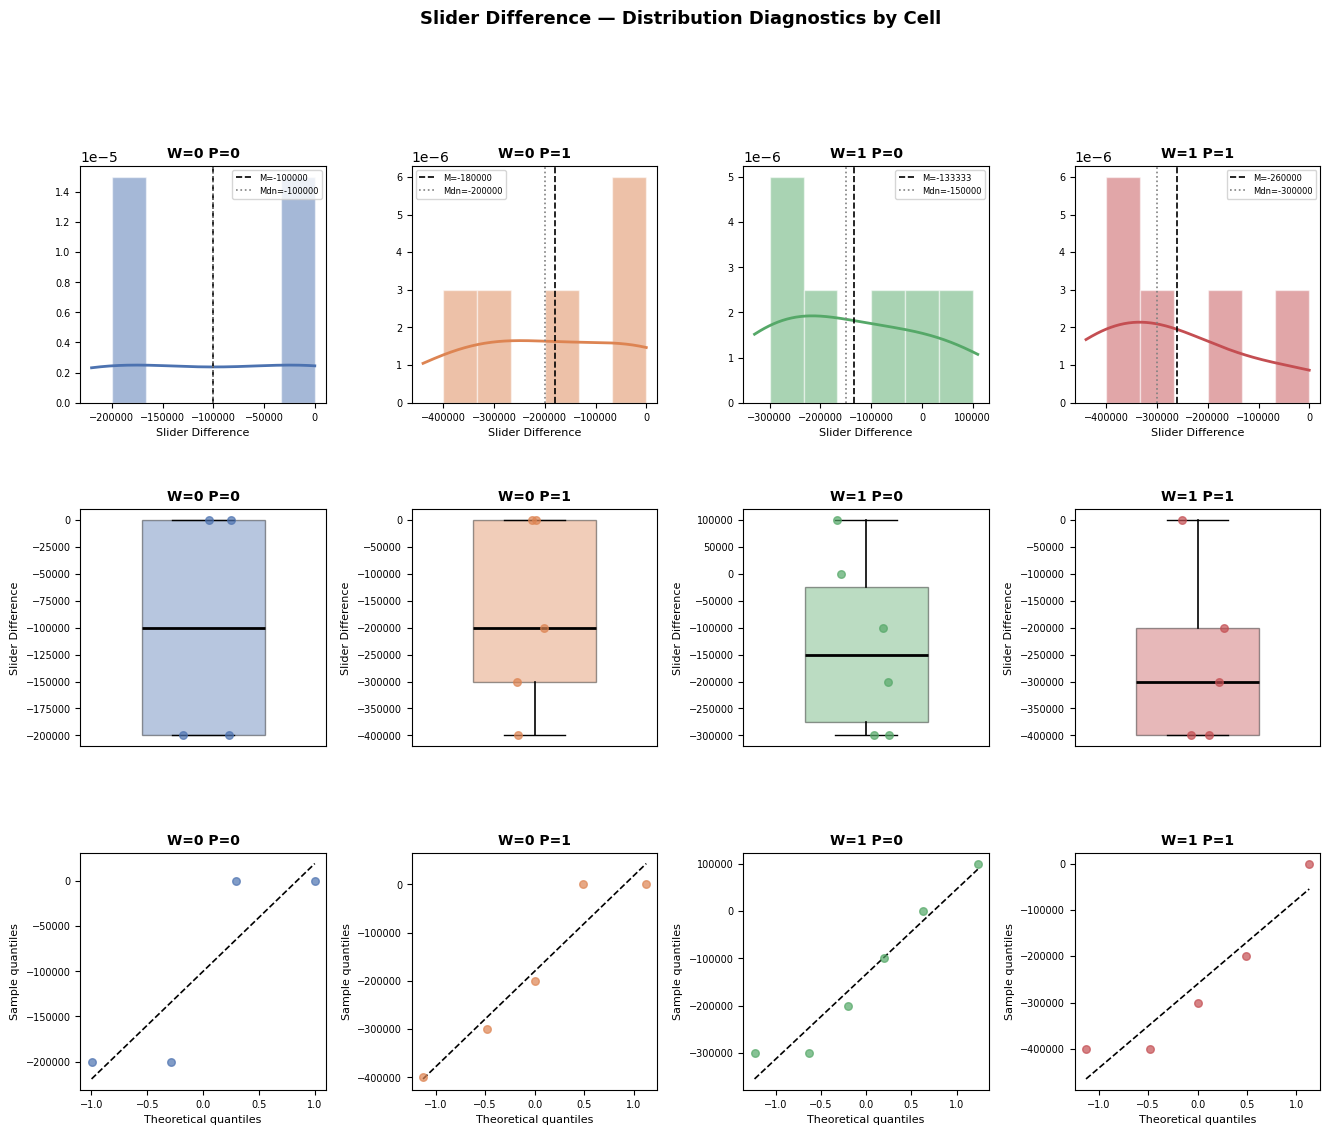


=== OUTLIER SUMMARY (±1.5 IQR) ===

  W=0 P=0: 0 outlier(s)

  W=0 P=1: 0 outlier(s)

  W=1 P=0: 0 outlier(s)

  W=1 P=1: 0 outlier(s)

=== SKEWNESS & KURTOSIS ===
  W=0 P=0: skew=0.000, kurtosis=-6.000
  W=0 P=1: skew=-0.052, kurtosis=-2.324
  W=1 P=0: skew=0.383, kurtosis=-1.481
  W=1 P=1: skew=1.089, kurtosis=0.536


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

conditions = [(0,0), (0,1), (1,0), (1,1)]
labels = ["W=0 P=0", "W=0 P=1", "W=1 P=0", "W=1 P=1"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

# ── Row 1: Histograms with KDE ────────────────────────────────────────────────
for i, ((w, p), label, color) in enumerate(zip(conditions, labels, colors)):
    ax = fig.add_subplot(gs[0, i])
    data = df[(df["Warmth"] == w) & (df["Personalization"] == p)]["Slider_Difference"].dropna()
    
    ax.hist(data, bins=6, color=color, alpha=0.5, edgecolor="white", density=True)
    
    xmin, xmax = data.min(), data.max()
    x = np.linspace(xmin - abs(xmin)*0.1, xmax + abs(xmax)*0.1, 200)
    kde = stats.gaussian_kde(data)
    ax.plot(x, kde(x), color=color, lw=2)
    ax.axvline(data.mean(), color="black", lw=1.2, linestyle="--", label=f"M={data.mean():.0f}")
    ax.axvline(data.median(), color="gray", lw=1.2, linestyle=":", label=f"Mdn={data.median():.0f}")
    
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("Slider Difference", fontsize=8)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)

# ── Row 2: Boxplots with jittered raw data ────────────────────────────────────
for i, ((w, p), label, color) in enumerate(zip(conditions, labels, colors)):
    ax = fig.add_subplot(gs[1, i])
    data = df[(df["Warmth"] == w) & (df["Personalization"] == p)]["Slider_Difference"].dropna()
    
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    boxprops=dict(facecolor=color, alpha=0.4),
                    medianprops=dict(color="black", lw=2),
                    whiskerprops=dict(lw=1.2),
                    flierprops=dict(marker="o", markerfacecolor=color, markersize=6, alpha=0.7))
    
    jitter = np.random.uniform(-0.12, 0.12, size=len(data))
    ax.scatter(1 + jitter, data, color=color, alpha=0.7, s=30, zorder=5)
    
    # Annotate outliers (beyond 1.5 IQR)
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    outliers = data[(data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)]
    for idx, val in outliers.items():
        ax.annotate(f"idx={idx}", xy=(1, val), xytext=(1.2, val),
                    fontsize=6, color="red", va="center")
    
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylabel("Slider Difference", fontsize=8)
    ax.set_xticks([])
    ax.tick_params(labelsize=7)

# ── Row 3: Q-Q plots ──────────────────────────────────────────────────────────
for i, ((w, p), label, color) in enumerate(zip(conditions, labels, colors)):
    ax = fig.add_subplot(gs[2, i])
    data = df[(df["Warmth"] == w) & (df["Personalization"] == p)]["Slider_Difference"].dropna()
    
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
    ax.scatter(osm, osr, color=color, alpha=0.7, s=30, zorder=5)
    x_line = np.array([min(osm), max(osm)])
    ax.plot(x_line, slope * x_line + intercept, color="black", lw=1.2, linestyle="--")
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("Theoretical quantiles", fontsize=8)
    ax.set_ylabel("Sample quantiles", fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle("Slider Difference — Distribution Diagnostics by Cell", 
             fontsize=13, fontweight="bold", y=1.01)

plt.savefig("slider_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Outlier summary table ─────────────────────────────────────────────────────
print("\n=== OUTLIER SUMMARY (±1.5 IQR) ===")
for (w, p), label in zip(conditions, labels):
    data = df[(df["Warmth"] == w) & (df["Personalization"] == p)]["Slider_Difference"].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    outliers = data[(data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)]
    print(f"\n  {label}: {len(outliers)} outlier(s)")
    for idx, val in outliers.items():
        z = (val - data.mean()) / data.std()
        print(f"    index={idx}, value={val:.1f}, z={z:.2f}")

# ── Skewness and kurtosis ─────────────────────────────────────────────────────
print("\n=== SKEWNESS & KURTOSIS ===")
for (w, p), label in zip(conditions, labels):
    data = df[(df["Warmth"] == w) & (df["Personalization"] == p)]["Slider_Difference"].dropna()
    print(f"  {label}: skew={data.skew():.3f}, kurtosis={data.kurtosis():.3f}")

=== WINSORIZATION LOG ===
  {'Warmth': 0, 'Personalization': 0}: clipped 0 value(s) → [-388675, 188675]
  {'Warmth': 0, 'Personalization': 1}: clipped 0 value(s) → [-627214, 267214]
  {'Warmth': 1, 'Personalization': 0}: clipped 0 value(s) → [-541582, 274915]
  {'Warmth': 1, 'Personalization': 1}: clipped 0 value(s) → [-678330, 158330]

=== OPTION 2: TWO-WAY ANOVA (Winsorized) ===
                                    sum_sq    df       F  PR(>F)
Intercept                     4.000000e+10   1.0  1.5484  0.2313
C(Warmth)                     2.666667e+09   1.0  0.1032  0.7522
C(Personalization)            1.422222e+10   1.0  0.5505  0.4689
C(Warmth):C(Personalization)  2.666667e+09   1.0  0.1032  0.7522
Residual                      4.133333e+11  16.0     NaN     NaN

=== OPTION 2: PARTIAL ETA-SQUARED (Winsorized) ===
  C(Warmth): partial η² = 0.0064
  C(Personalization): partial η² = 0.0333
  C(Warmth):C(Personalization): partial η² = 0.0064

=== OPTION 2: POST-HOC TUKEY (Winsorized) ===


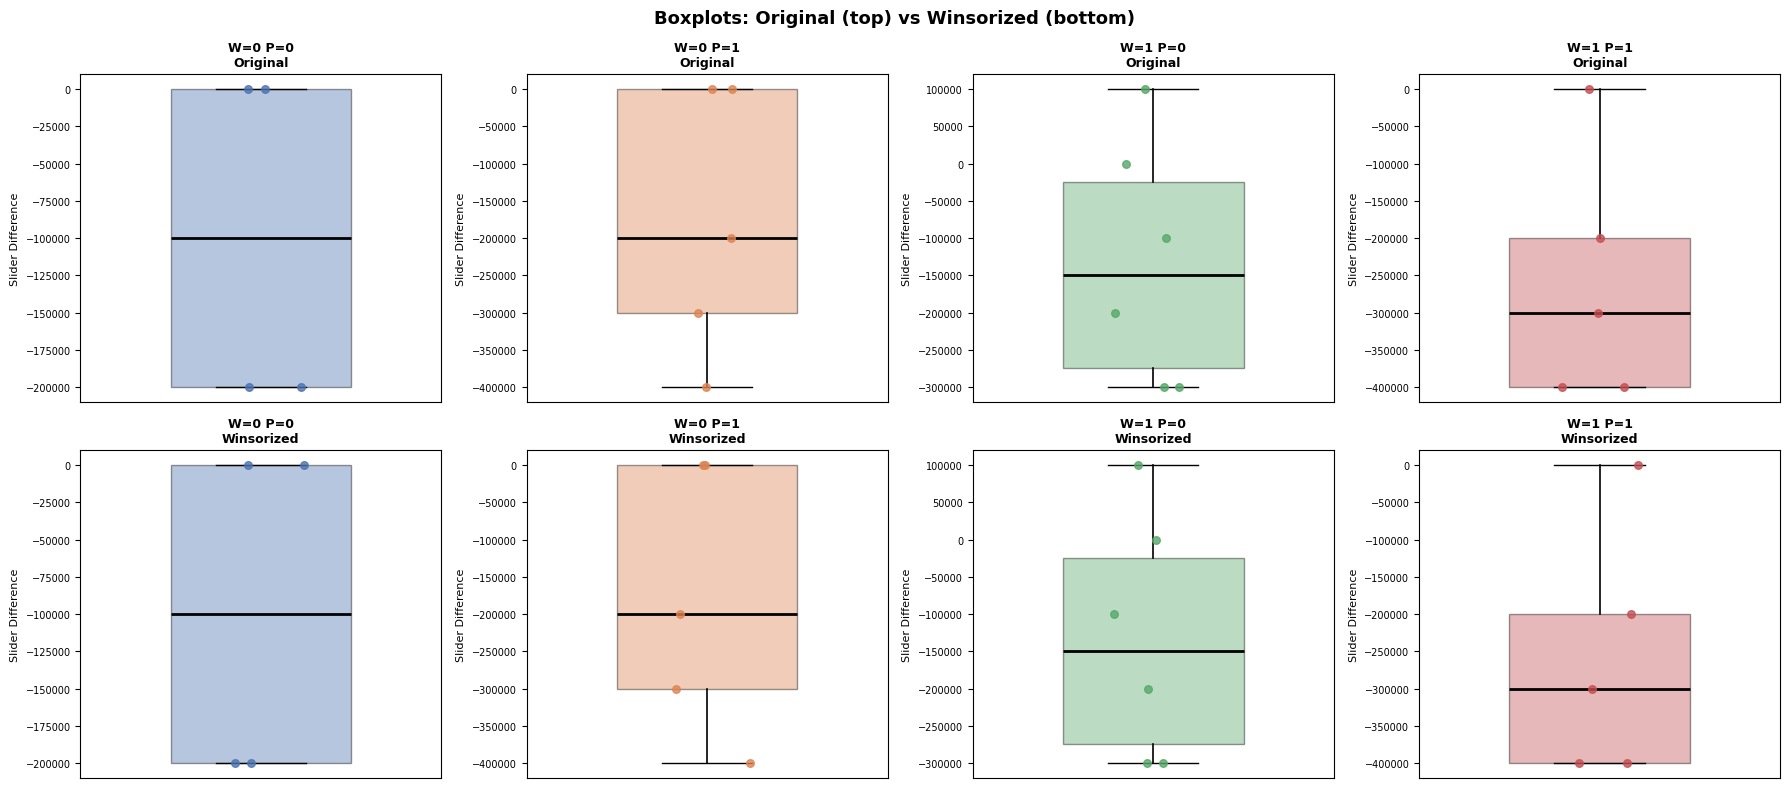

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import pingouin as pg
from itertools import combinations

conditions = [(0,0), (0,1), (1,0), (1,1)]
labels     = ["W=0 P=0", "W=0 P=1", "W=1 P=0", "W=1 P=1"]
colors     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

# ═══════════════════════════════════════════════════════════════════════════════
# OPTION 2 — WINSORIZATION (±2.5 SD per cell)
# ═══════════════════════════════════════════════════════════════════════════════

def winsorize_by_cell(df, dv, group_cols, threshold=2.5):
    df_clean = df.copy()
    print("=== WINSORIZATION LOG ===")
    for keys, grp in df.groupby(group_cols):
        idx  = grp.index
        m, s = grp[dv].mean(), grp[dv].std()
        lower, upper = m - threshold * s, m + threshold * s
        n_clipped = ((grp[dv] < lower) | (grp[dv] > upper)).sum()
        df_clean.loc[idx, dv] = df_clean.loc[idx, dv].clip(lower, upper)
        keys_str = dict(zip(group_cols, keys if isinstance(keys, tuple) else [keys]))
        print(f"  {keys_str}: clipped {n_clipped} value(s) → [{lower:.0f}, {upper:.0f}]")
    return df_clean

df_winsorized = winsorize_by_cell(df, "Slider_Difference", ["Warmth", "Personalization"])

# ── Two-way ANOVA on winsorized data ─────────────────────────────────────────
print("\n=== OPTION 2: TWO-WAY ANOVA (Winsorized) ===")
model_w = ols("Slider_Difference ~ C(Warmth) * C(Personalization)", data=df_winsorized).fit()
table_w = anova_lm(model_w, typ=3)
print(table_w.round(4))

print("\n=== OPTION 2: PARTIAL ETA-SQUARED (Winsorized) ===")
ss_res_w = table_w.loc["Residual", "sum_sq"]
for term in ["C(Warmth)", "C(Personalization)", "C(Warmth):C(Personalization)"]:
    ss_e   = table_w.loc[term, "sum_sq"]
    eta_sq = ss_e / (ss_e + ss_res_w)
    print(f"  {term}: partial η² = {eta_sq:.4f}")

print("\n=== OPTION 2: POST-HOC TUKEY (Winsorized) ===")
df_winsorized["condition"] = (df_winsorized["Warmth"].astype(str) + "_" +
                               df_winsorized["Personalization"].astype(str))
posthoc_w = pg.pairwise_tukey(data=df_winsorized, dv="Slider_Difference", between="condition")
print(posthoc_w.round(4))

# ── Normality re-check after winsorization ────────────────────────────────────
print("\n=== OPTION 2: NORMALITY RE-CHECK (Shapiro-Wilk, Winsorized) ===")
for (w, p), label in zip(conditions, labels):
    data = df_winsorized[
        (df_winsorized["Warmth"] == w) & (df_winsorized["Personalization"] == p)
    ]["Slider_Difference"].dropna()
    stat, pval = stats.shapiro(data)
    print(f"  {label} → W={stat:.3f}, p={pval:.3f}")

# ═══════════════════════════════════════════════════════════════════════════════
# OPTION 1 — ROBUST / NON-PARAMETRIC
# ═══════════════════════════════════════════════════════════════════════════════

# ── Kruskal-Wallis (omnibus non-parametric equivalent of one-way ANOVA) ───────
print("\n=== OPTION 1: KRUSKAL-WALLIS (omnibus across all 4 cells) ===")
groups_kw = [
    df[(df["Warmth"] == w) & (df["Personalization"] == p)]["Slider_Difference"].dropna().values
    for (w, p) in conditions
]
h_stat, p_kw = stats.kruskal(*groups_kw)
print(f"  H={h_stat:.3f}, p={p_kw:.4f}")

# ── Mann-Whitney pairwise (with Bonferroni correction) ────────────────────────
print("\n=== OPTION 1: MANN-WHITNEY PAIRWISE (Bonferroni corrected) ===")
n_comparisons = len(list(combinations(range(4), 2)))
rows = []
for (i, j) in combinations(range(4), 2):
    d1 = df[(df["Warmth"] == conditions[i][0]) &
            (df["Personalization"] == conditions[i][1])]["Slider_Difference"].dropna()
    d2 = df[(df["Warmth"] == conditions[j][0]) &
            (df["Personalization"] == conditions[j][1])]["Slider_Difference"].dropna()
    
    u_stat, p_val = mannwhitneyu(d1, d2, alternative="two-sided")
    p_bonf = min(p_val * n_comparisons, 1.0)
    
    # Rank-biserial correlation as effect size
    n1, n2  = len(d1), len(d2)
    r_rb    = 1 - (2 * u_stat) / (n1 * n2)
    
    rows.append({
        "Comparison":  f"{labels[i]} vs {labels[j]}",
        "U":           round(u_stat, 1),
        "p (raw)":     round(p_val, 4),
        "p (Bonf)":    round(p_bonf, 4),
        "r_rb":        round(r_rb, 4),
    })

mw_table = pd.DataFrame(rows)
print(mw_table.to_string(index=False))

# ── Permutation ANOVA (main effects + interaction, robust to non-normality) ───
def permutation_anova(df, dv, iv1, iv2, n_permutations=10000, seed=42):
    np.random.seed(seed)

    def get_f_stats(data):
        model = ols(f"{dv} ~ C({iv1}) * C({iv2})", data=data).fit()
        table = anova_lm(model, typ=3)
        return {
            iv1:           table.loc[f"C({iv1})",           "F"],
            iv2:           table.loc[f"C({iv2})",           "F"],
            "interaction": table.loc[f"C({iv1}):C({iv2})",  "F"],
        }

    observed = get_f_stats(df)
    counts   = {k: 0 for k in observed}

    for _ in range(n_permutations):
        perm    = df.copy()
        perm[dv] = np.random.permutation(perm[dv].values)
        perm_f  = get_f_stats(perm)
        for k in observed:
            if perm_f[k] >= observed[k]:
                counts[k] += 1

    print(f"\n=== OPTION 1: PERMUTATION ANOVA ({n_permutations:,} permutations) ===")
    for k, f_obs in observed.items():
        p_perm = counts[k] / n_permutations
        sig    = "✓" if p_perm < .05 else "✗"
        print(f"  {k:<20}  F={f_obs:.3f},  p_perm={p_perm:.4f}  {sig}")

permutation_anova(df, "Slider_Difference", "Warmth", "Personalization")

# ═══════════════════════════════════════════════════════════════════════════════
# SENSITIVITY ANALYSIS — side-by-side comparison
# ═══════════════════════════════════════════════════════════════════════════════

print("\n=== SENSITIVITY ANALYSIS: ORIGINAL vs WINSORIZED ===")
print(f"  {'Term':<45} {'Original':>20}  {'Winsorized':>20}")
print("  " + "─" * 87)

model_o = ols("Slider_Difference ~ C(Warmth) * C(Personalization)", data=df).fit()
table_o = anova_lm(model_o, typ=3)
ss_res_o = table_o.loc["Residual", "sum_sq"]

for term in ["C(Warmth)", "C(Personalization)", "C(Warmth):C(Personalization)"]:
    f_o  = table_o.loc[term, "F"]
    p_o  = table_o.loc[term, "PR(>F)"]
    eta_o = table_o.loc[term, "sum_sq"] / (table_o.loc[term, "sum_sq"] + ss_res_o)

    f_w  = table_w.loc[term, "F"]
    p_w  = table_w.loc[term, "PR(>F)"]
    eta_w = table_w.loc[term, "sum_sq"] / (table_w.loc[term, "sum_sq"] + ss_res_w)

    orig_str = f"F={f_o:.3f}, p={p_o:.3f}, η²={eta_o:.4f}"
    wins_str = f"F={f_w:.3f}, p={p_w:.3f}, η²={eta_w:.4f}"
    print(f"  {term:<45} {orig_str:>20}  {wins_str:>20}")

# ═══════════════════════════════════════════════════════════════════════════════
# DIAGNOSTIC PLOTS — Original vs Winsorized side by side
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Boxplots: Original (top) vs Winsorized (bottom)", fontsize=13, fontweight="bold")

for col, ((w, p), label, color) in enumerate(zip(conditions, labels, colors)):
    for row, (dataset, title_suffix) in enumerate([(df, "Original"), (df_winsorized, "Winsorized")]):
        ax   = axes[row, col]
        data = dataset[
            (dataset["Warmth"] == w) & (dataset["Personalization"] == p)
        ]["Slider_Difference"].dropna()

        ax.boxplot(data, patch_artist=True, widths=0.5,
                   boxprops=dict(facecolor=color, alpha=0.4),
                   medianprops=dict(color="black", lw=2),
                   whiskerprops=dict(lw=1.2),
                   flierprops=dict(marker="o", markerfacecolor=color, markersize=6, alpha=0.7))

        jitter = np.random.uniform(-0.12, 0.12, size=len(data))
        ax.scatter(1 + jitter, data, color=color, alpha=0.8, s=30, zorder=5)

        ax.set_title(f"{label}\n{title_suffix}", fontsize=9, fontweight="bold")
        ax.set_ylabel("Slider Difference", fontsize=8)
        ax.set_xticks([])
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("sensitivity_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

=== WINSORIZATION LOG ===
  {'Warmth': 0, 'Personalization': 0}: clipped 0 value(s) → [-1052163, 984328]
  {'Warmth': 0, 'Personalization': 1}: clipped 0 value(s) → [-1346940, 1370845]
  {'Warmth': 1, 'Personalization': 0}: clipped 0 value(s) → [-1608000, 1716958]
  {'Warmth': 1, 'Personalization': 1}: clipped 0 value(s) → [-865301, 364243]

=== OPTION 2: TWO-WAY ANOVA (Winsorized) ===
                                    sum_sq    df       F  PR(>F)
Intercept                     6.902449e+09   1.0  0.0309  0.8628
C(Warmth)                     1.875353e+10   1.0  0.0838  0.7759
C(Personalization)            5.738404e+09   1.0  0.0256  0.8748
C(Warmth):C(Personalization)  1.507539e+11   1.0  0.6738  0.4238
Residual                      3.579801e+12  16.0     NaN     NaN

=== OPTION 2: PARTIAL ETA-SQUARED (Winsorized) ===
  C(Warmth): partial η² = 0.0052
  C(Personalization): partial η² = 0.0016
  C(Warmth):C(Personalization): partial η² = 0.0404

=== OPTION 2: POST-HOC TUKEY (Winsorized)

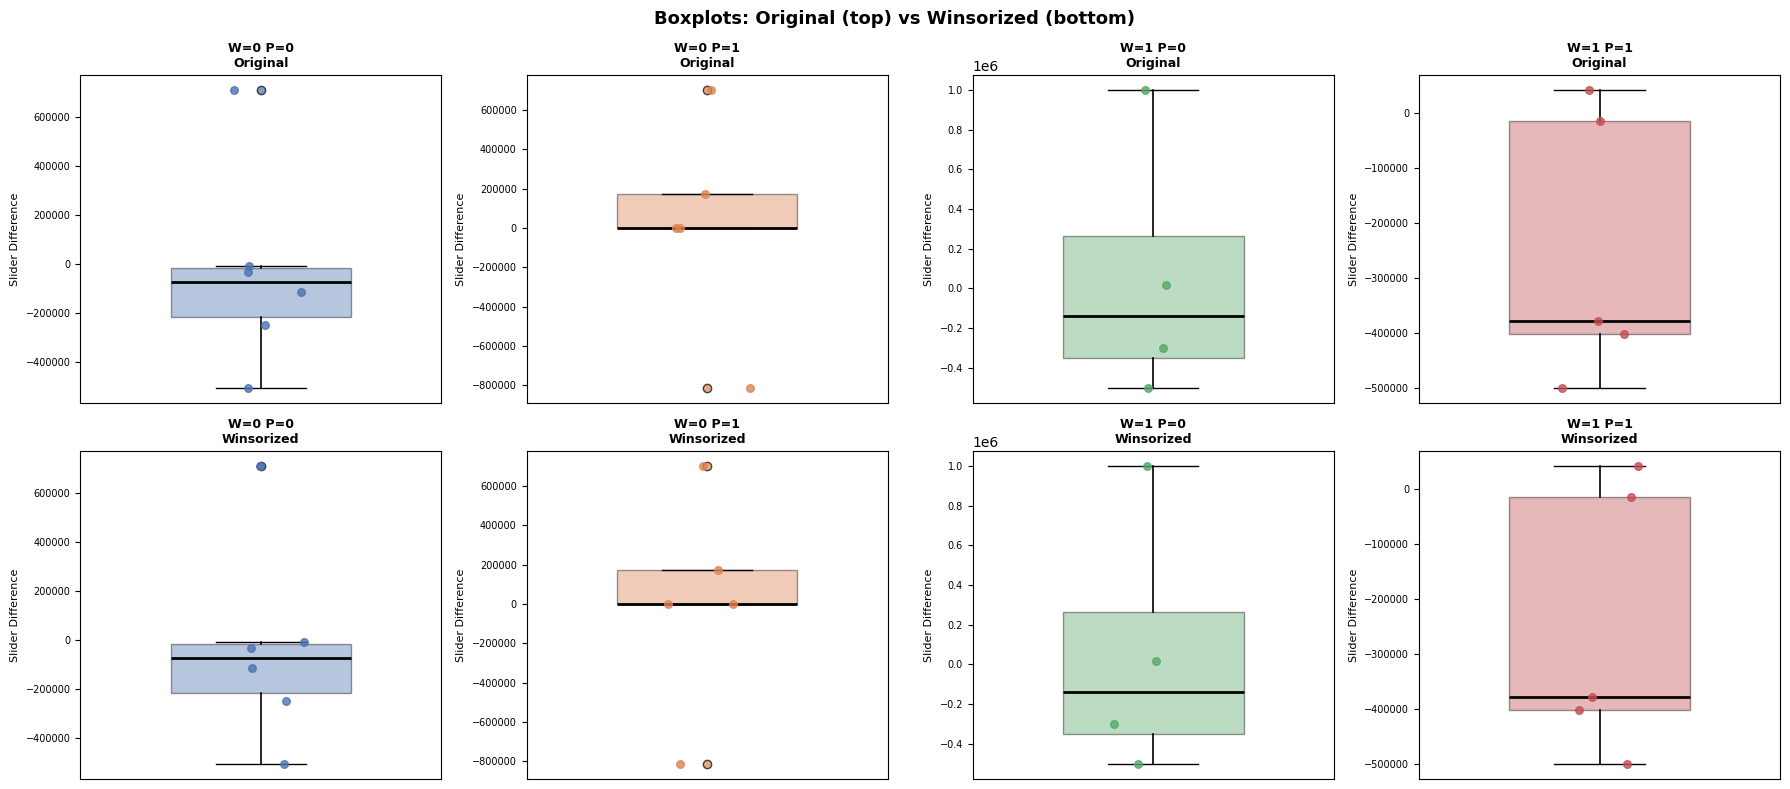

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import pingouin as pg
from itertools import combinations

conditions = [(0,0), (0,1), (1,0), (1,1)]
labels     = ["W=0 P=0", "W=0 P=1", "W=1 P=0", "W=1 P=1"]
colors     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

# ═══════════════════════════════════════════════════════════════════════════════
# OPTION 2 — WINSORIZATION (±2.5 SD per cell)
# ═══════════════════════════════════════════════════════════════════════════════

def winsorize_by_cell(df, dv, group_cols, threshold=2.5):
    df_clean = df.copy()
    print("=== WINSORIZATION LOG ===")
    for keys, grp in df.groupby(group_cols):
        idx  = grp.index
        m, s = grp[dv].mean(), grp[dv].std()
        lower, upper = m - threshold * s, m + threshold * s
        n_clipped = ((grp[dv] < lower) | (grp[dv] > upper)).sum()
        df_clean.loc[idx, dv] = df_clean.loc[idx, dv].clip(lower, upper)
        keys_str = dict(zip(group_cols, keys if isinstance(keys, tuple) else [keys]))
        print(f"  {keys_str}: clipped {n_clipped} value(s) → [{lower:.0f}, {upper:.0f}]")
    return df_clean

df_winsorized = winsorize_by_cell(df, "Slider_Difference", ["Warmth", "Personalization"])

# ── Two-way ANOVA on winsorized data ─────────────────────────────────────────
print("\n=== OPTION 2: TWO-WAY ANOVA (Winsorized) ===")
model_w = ols("Slider_Difference ~ C(Warmth) * C(Personalization)", data=df_winsorized).fit()
table_w = anova_lm(model_w, typ=3)
print(table_w.round(4))

print("\n=== OPTION 2: PARTIAL ETA-SQUARED (Winsorized) ===")
ss_res_w = table_w.loc["Residual", "sum_sq"]
for term in ["C(Warmth)", "C(Personalization)", "C(Warmth):C(Personalization)"]:
    ss_e   = table_w.loc[term, "sum_sq"]
    eta_sq = ss_e / (ss_e + ss_res_w)
    print(f"  {term}: partial η² = {eta_sq:.4f}")

print("\n=== OPTION 2: POST-HOC TUKEY (Winsorized) ===")
df_winsorized["condition"] = (df_winsorized["Warmth"].astype(str) + "_" +
                               df_winsorized["Personalization"].astype(str))
posthoc_w = pg.pairwise_tukey(data=df_winsorized, dv="Slider_Difference", between="condition")
print(posthoc_w.round(4))

# ── Normality re-check after winsorization ────────────────────────────────────
print("\n=== OPTION 2: NORMALITY RE-CHECK (Shapiro-Wilk, Winsorized) ===")
for (w, p), label in zip(conditions, labels):
    data = df_winsorized[
        (df_winsorized["Warmth"] == w) & (df_winsorized["Personalization"] == p)
    ]["Slider_Difference"].dropna()
    stat, pval = stats.shapiro(data)
    print(f"  {label} → W={stat:.3f}, p={pval:.3f}")

# ═══════════════════════════════════════════════════════════════════════════════
# OPTION 1 — ROBUST / NON-PARAMETRIC
# ═══════════════════════════════════════════════════════════════════════════════

# ── Kruskal-Wallis (omnibus non-parametric equivalent of one-way ANOVA) ───────
print("\n=== OPTION 1: KRUSKAL-WALLIS (omnibus across all 4 cells) ===")
groups_kw = [
    df[(df["Warmth"] == w) & (df["Personalization"] == p)]["Slider_Difference"].dropna().values
    for (w, p) in conditions
]
h_stat, p_kw = stats.kruskal(*groups_kw)
print(f"  H={h_stat:.3f}, p={p_kw:.4f}")

# ── Mann-Whitney pairwise (with Bonferroni correction) ────────────────────────
print("\n=== OPTION 1: MANN-WHITNEY PAIRWISE (Bonferroni corrected) ===")
n_comparisons = len(list(combinations(range(4), 2)))
rows = []
for (i, j) in combinations(range(4), 2):
    d1 = df[(df["Warmth"] == conditions[i][0]) &
            (df["Personalization"] == conditions[i][1])]["Slider_Difference"].dropna()
    d2 = df[(df["Warmth"] == conditions[j][0]) &
            (df["Personalization"] == conditions[j][1])]["Slider_Difference"].dropna()
    
    u_stat, p_val = mannwhitneyu(d1, d2, alternative="two-sided")
    p_bonf = min(p_val * n_comparisons, 1.0)
    
    # Rank-biserial correlation as effect size
    n1, n2  = len(d1), len(d2)
    r_rb    = 1 - (2 * u_stat) / (n1 * n2)
    
    rows.append({
        "Comparison":  f"{labels[i]} vs {labels[j]}",
        "U":           round(u_stat, 1),
        "p (raw)":     round(p_val, 4),
        "p (Bonf)":    round(p_bonf, 4),
        "r_rb":        round(r_rb, 4),
    })

mw_table = pd.DataFrame(rows)
print(mw_table.to_string(index=False))

# ── Permutation ANOVA (main effects + interaction, robust to non-normality) ───
def permutation_anova(df, dv, iv1, iv2, n_permutations=10000, seed=42):
    np.random.seed(seed)

    def get_f_stats(data):
        model = ols(f"{dv} ~ C({iv1}) * C({iv2})", data=data).fit()
        table = anova_lm(model, typ=3)
        return {
            iv1:           table.loc[f"C({iv1})",           "F"],
            iv2:           table.loc[f"C({iv2})",           "F"],
            "interaction": table.loc[f"C({iv1}):C({iv2})",  "F"],
        }

    observed = get_f_stats(df)
    counts   = {k: 0 for k in observed}

    for _ in range(n_permutations):
        perm    = df.copy()
        perm[dv] = np.random.permutation(perm[dv].values)
        perm_f  = get_f_stats(perm)
        for k in observed:
            if perm_f[k] >= observed[k]:
                counts[k] += 1

    print(f"\n=== OPTION 1: PERMUTATION ANOVA ({n_permutations:,} permutations) ===")
    for k, f_obs in observed.items():
        p_perm = counts[k] / n_permutations
        sig    = "✓" if p_perm < .05 else "✗"
        print(f"  {k:<20}  F={f_obs:.3f},  p_perm={p_perm:.4f}  {sig}")

permutation_anova(df, "Slider_Difference", "Warmth", "Personalization")

# ═══════════════════════════════════════════════════════════════════════════════
# SENSITIVITY ANALYSIS — side-by-side comparison
# ═══════════════════════════════════════════════════════════════════════════════

print("\n=== SENSITIVITY ANALYSIS: ORIGINAL vs WINSORIZED ===")
print(f"  {'Term':<45} {'Original':>20}  {'Winsorized':>20}")
print("  " + "─" * 87)

model_o = ols("Slider_Difference ~ C(Warmth) * C(Personalization)", data=df).fit()
table_o = anova_lm(model_o, typ=3)
ss_res_o = table_o.loc["Residual", "sum_sq"]

for term in ["C(Warmth)", "C(Personalization)", "C(Warmth):C(Personalization)"]:
    f_o  = table_o.loc[term, "F"]
    p_o  = table_o.loc[term, "PR(>F)"]
    eta_o = table_o.loc[term, "sum_sq"] / (table_o.loc[term, "sum_sq"] + ss_res_o)

    f_w  = table_w.loc[term, "F"]
    p_w  = table_w.loc[term, "PR(>F)"]
    eta_w = table_w.loc[term, "sum_sq"] / (table_w.loc[term, "sum_sq"] + ss_res_w)

    orig_str = f"F={f_o:.3f}, p={p_o:.3f}, η²={eta_o:.4f}"
    wins_str = f"F={f_w:.3f}, p={p_w:.3f}, η²={eta_w:.4f}"
    print(f"  {term:<45} {orig_str:>20}  {wins_str:>20}")

# ═══════════════════════════════════════════════════════════════════════════════
# DIAGNOSTIC PLOTS — Original vs Winsorized side by side
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Boxplots: Original (top) vs Winsorized (bottom)", fontsize=13, fontweight="bold")

for col, ((w, p), label, color) in enumerate(zip(conditions, labels, colors)):
    for row, (dataset, title_suffix) in enumerate([(df, "Original"), (df_winsorized, "Winsorized")]):
        ax   = axes[row, col]
        data = dataset[
            (dataset["Warmth"] == w) & (dataset["Personalization"] == p)
        ]["Slider_Difference"].dropna()

        ax.boxplot(data, patch_artist=True, widths=0.5,
                   boxprops=dict(facecolor=color, alpha=0.4),
                   medianprops=dict(color="black", lw=2),
                   whiskerprops=dict(lw=1.2),
                   flierprops=dict(marker="o", markerfacecolor=color, markersize=6, alpha=0.7))

        jitter = np.random.uniform(-0.12, 0.12, size=len(data))
        ax.scatter(1 + jitter, data, color=color, alpha=0.8, s=30, zorder=5)

        ax.set_title(f"{label}\n{title_suffix}", fontsize=9, fontweight="bold")
        ax.set_ylabel("Slider Difference", fontsize=8)
        ax.set_xticks([])
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("sensitivity_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

=== WINSORIZATION LOG ===
  {'Warmth': 0, 'Personalization': 0}: clipped 0 value(s) → [-842060, 721358]
  {'Warmth': 0, 'Personalization': 1}: clipped 0 value(s) → [-1070717, 902669]
  {'Warmth': 1, 'Personalization': 0}: clipped 1 value(s) → [-1093902, 977485]
  {'Warmth': 1, 'Personalization': 1}: clipped 0 value(s) → [-751156, 240627]

=== OPTION 2: TWO-WAY ANOVA (Winsorized) ===
                                    sum_sq    df       F  PR(>F)
Intercept                     3.642195e+10   1.0  0.3170  0.5769
C(Warmth)                     6.946332e+03   1.0  0.0000  0.9998
C(Personalization)            2.802078e+09   1.0  0.0244  0.8768
C(Warmth):C(Personalization)  7.334053e+10   1.0  0.6383  0.4296
Residual                      4.136521e+12  36.0     NaN     NaN

=== OPTION 2: PARTIAL ETA-SQUARED (Winsorized) ===
  C(Warmth): partial η² = 0.0000
  C(Personalization): partial η² = 0.0007
  C(Warmth):C(Personalization): partial η² = 0.0174

=== OPTION 2: POST-HOC TUKEY (Winsorized) ==

/var/folders/95/zkvys7lx2rz56fr237pxw5g40000gn/T/ipykernel_88481/1727571688.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-300000.         -200000.               0.         -300000.
 -100000.          100000.           19976.          977484.72864703
 -298886.         -501708.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_clean.loc[idx, dv] = df_clean.loc[idx, dv].clip(lower, upper)



=== OPTION 1: PERMUTATION ANOVA (10,000 permutations) ===
  Warmth                F=0.000,  p_perm=0.9898  ✗
  Personalization       F=0.024,  p_perm=0.8773  ✗
  interaction           F=0.647,  p_perm=0.4411  ✗

=== SENSITIVITY ANALYSIS: ORIGINAL vs WINSORIZED ===
  Term                                                      Original            Winsorized
  ───────────────────────────────────────────────────────────────────────────────────────
  C(Warmth)                                     F=0.000, p=0.989, η²=0.0000  F=0.000, p=1.000, η²=0.0000
  C(Personalization)                            F=0.024, p=0.877, η²=0.0007  F=0.024, p=0.877, η²=0.0007
  C(Warmth):C(Personalization)                  F=0.647, p=0.426, η²=0.0177  F=0.638, p=0.430, η²=0.0174


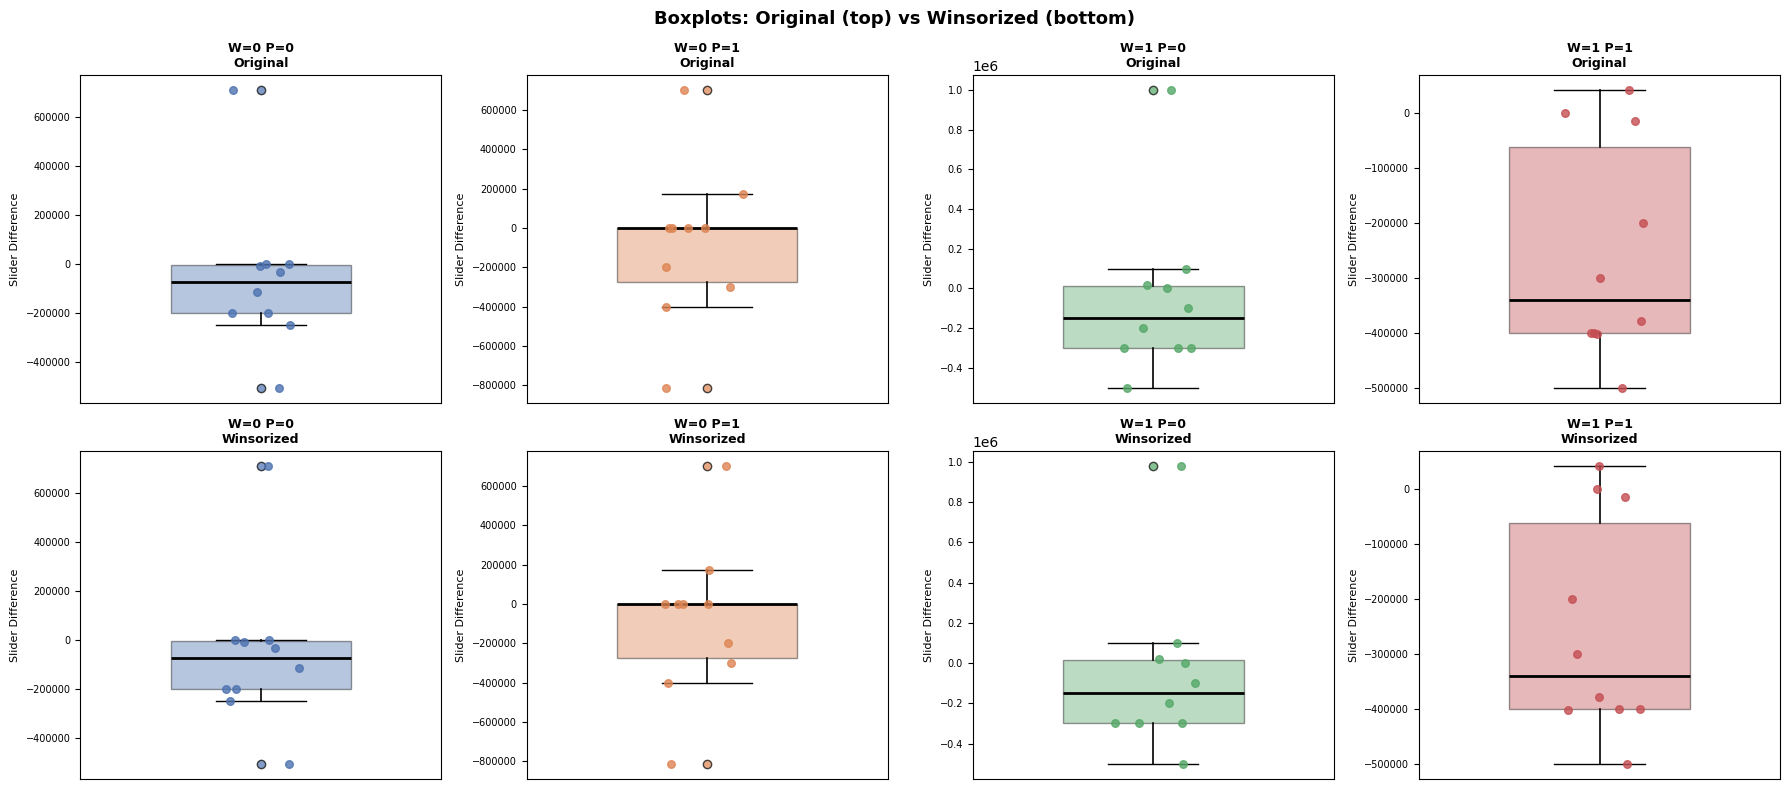

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import pingouin as pg
from itertools import combinations

conditions = [(0,0), (0,1), (1,0), (1,1)]
labels     = ["W=0 P=0", "W=0 P=1", "W=1 P=0", "W=1 P=1"]
colors     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

# ═══════════════════════════════════════════════════════════════════════════════
# OPTION 2 — WINSORIZATION (±2.5 SD per cell)
# ═══════════════════════════════════════════════════════════════════════════════

def winsorize_by_cell(df, dv, group_cols, threshold=2.5):
    df_clean = df.copy()
    print("=== WINSORIZATION LOG ===")
    for keys, grp in df.groupby(group_cols):
        idx  = grp.index
        m, s = grp[dv].mean(), grp[dv].std()
        lower, upper = m - threshold * s, m + threshold * s
        n_clipped = ((grp[dv] < lower) | (grp[dv] > upper)).sum()
        df_clean.loc[idx, dv] = df_clean.loc[idx, dv].clip(lower, upper)
        keys_str = dict(zip(group_cols, keys if isinstance(keys, tuple) else [keys]))
        print(f"  {keys_str}: clipped {n_clipped} value(s) → [{lower:.0f}, {upper:.0f}]")
    return df_clean

df_winsorized = winsorize_by_cell(df, "Slider_Difference", ["Warmth", "Personalization"])

# ── Two-way ANOVA on winsorized data ─────────────────────────────────────────
print("\n=== OPTION 2: TWO-WAY ANOVA (Winsorized) ===")
model_w = ols("Slider_Difference ~ C(Warmth) * C(Personalization)", data=df_winsorized).fit()
table_w = anova_lm(model_w, typ=3)
print(table_w.round(4))

print("\n=== OPTION 2: PARTIAL ETA-SQUARED (Winsorized) ===")
ss_res_w = table_w.loc["Residual", "sum_sq"]
for term in ["C(Warmth)", "C(Personalization)", "C(Warmth):C(Personalization)"]:
    ss_e   = table_w.loc[term, "sum_sq"]
    eta_sq = ss_e / (ss_e + ss_res_w)
    print(f"  {term}: partial η² = {eta_sq:.4f}")

print("\n=== OPTION 2: POST-HOC TUKEY (Winsorized) ===")
df_winsorized["condition"] = (df_winsorized["Warmth"].astype(str) + "_" +
                               df_winsorized["Personalization"].astype(str))
posthoc_w = pg.pairwise_tukey(data=df_winsorized, dv="Slider_Difference", between="condition")
print(posthoc_w.round(4))

# ── Normality re-check after winsorization ────────────────────────────────────
print("\n=== OPTION 2: NORMALITY RE-CHECK (Shapiro-Wilk, Winsorized) ===")
for (w, p), label in zip(conditions, labels):
    data = df_winsorized[
        (df_winsorized["Warmth"] == w) & (df_winsorized["Personalization"] == p)
    ]["Slider_Difference"].dropna()
    stat, pval = stats.shapiro(data)
    print(f"  {label} → W={stat:.3f}, p={pval:.3f}")

# ═══════════════════════════════════════════════════════════════════════════════
# OPTION 1 — ROBUST / NON-PARAMETRIC
# ═══════════════════════════════════════════════════════════════════════════════

# ── Kruskal-Wallis (omnibus non-parametric equivalent of one-way ANOVA) ───────
print("\n=== OPTION 1: KRUSKAL-WALLIS (omnibus across all 4 cells) ===")
groups_kw = [
    df[(df["Warmth"] == w) & (df["Personalization"] == p)]["Slider_Difference"].dropna().values
    for (w, p) in conditions
]
h_stat, p_kw = stats.kruskal(*groups_kw)
print(f"  H={h_stat:.3f}, p={p_kw:.4f}")

# ── Mann-Whitney pairwise (with Bonferroni correction) ────────────────────────
print("\n=== OPTION 1: MANN-WHITNEY PAIRWISE (Bonferroni corrected) ===")
n_comparisons = len(list(combinations(range(4), 2)))
rows = []
for (i, j) in combinations(range(4), 2):
    d1 = df[(df["Warmth"] == conditions[i][0]) &
            (df["Personalization"] == conditions[i][1])]["Slider_Difference"].dropna()
    d2 = df[(df["Warmth"] == conditions[j][0]) &
            (df["Personalization"] == conditions[j][1])]["Slider_Difference"].dropna()
    
    u_stat, p_val = mannwhitneyu(d1, d2, alternative="two-sided")
    p_bonf = min(p_val * n_comparisons, 1.0)
    
    # Rank-biserial correlation as effect size
    n1, n2  = len(d1), len(d2)
    r_rb    = 1 - (2 * u_stat) / (n1 * n2)
    
    rows.append({
        "Comparison":  f"{labels[i]} vs {labels[j]}",
        "U":           round(u_stat, 1),
        "p (raw)":     round(p_val, 4),
        "p (Bonf)":    round(p_bonf, 4),
        "r_rb":        round(r_rb, 4),
    })

mw_table = pd.DataFrame(rows)
print(mw_table.to_string(index=False))

# ── Permutation ANOVA (main effects + interaction, robust to non-normality) ───
def permutation_anova(df, dv, iv1, iv2, n_permutations=10000, seed=42):
    np.random.seed(seed)

    def get_f_stats(data):
        model = ols(f"{dv} ~ C({iv1}) * C({iv2})", data=data).fit()
        table = anova_lm(model, typ=3)
        return {
            iv1:           table.loc[f"C({iv1})",           "F"],
            iv2:           table.loc[f"C({iv2})",           "F"],
            "interaction": table.loc[f"C({iv1}):C({iv2})",  "F"],
        }

    observed = get_f_stats(df)
    counts   = {k: 0 for k in observed}

    for _ in range(n_permutations):
        perm    = df.copy()
        perm[dv] = np.random.permutation(perm[dv].values)
        perm_f  = get_f_stats(perm)
        for k in observed:
            if perm_f[k] >= observed[k]:
                counts[k] += 1

    print(f"\n=== OPTION 1: PERMUTATION ANOVA ({n_permutations:,} permutations) ===")
    for k, f_obs in observed.items():
        p_perm = counts[k] / n_permutations
        sig    = "✓" if p_perm < .05 else "✗"
        print(f"  {k:<20}  F={f_obs:.3f},  p_perm={p_perm:.4f}  {sig}")

permutation_anova(df, "Slider_Difference", "Warmth", "Personalization")

# ═══════════════════════════════════════════════════════════════════════════════
# SENSITIVITY ANALYSIS — side-by-side comparison
# ═══════════════════════════════════════════════════════════════════════════════

print("\n=== SENSITIVITY ANALYSIS: ORIGINAL vs WINSORIZED ===")
print(f"  {'Term':<45} {'Original':>20}  {'Winsorized':>20}")
print("  " + "─" * 87)

model_o = ols("Slider_Difference ~ C(Warmth) * C(Personalization)", data=df).fit()
table_o = anova_lm(model_o, typ=3)
ss_res_o = table_o.loc["Residual", "sum_sq"]

for term in ["C(Warmth)", "C(Personalization)", "C(Warmth):C(Personalization)"]:
    f_o  = table_o.loc[term, "F"]
    p_o  = table_o.loc[term, "PR(>F)"]
    eta_o = table_o.loc[term, "sum_sq"] / (table_o.loc[term, "sum_sq"] + ss_res_o)

    f_w  = table_w.loc[term, "F"]
    p_w  = table_w.loc[term, "PR(>F)"]
    eta_w = table_w.loc[term, "sum_sq"] / (table_w.loc[term, "sum_sq"] + ss_res_w)

    orig_str = f"F={f_o:.3f}, p={p_o:.3f}, η²={eta_o:.4f}"
    wins_str = f"F={f_w:.3f}, p={p_w:.3f}, η²={eta_w:.4f}"
    print(f"  {term:<45} {orig_str:>20}  {wins_str:>20}")

# ═══════════════════════════════════════════════════════════════════════════════
# DIAGNOSTIC PLOTS — Original vs Winsorized side by side
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Boxplots: Original (top) vs Winsorized (bottom)", fontsize=13, fontweight="bold")

for col, ((w, p), label, color) in enumerate(zip(conditions, labels, colors)):
    for row, (dataset, title_suffix) in enumerate([(df, "Original"), (df_winsorized, "Winsorized")]):
        ax   = axes[row, col]
        data = dataset[
            (dataset["Warmth"] == w) & (dataset["Personalization"] == p)
        ]["Slider_Difference"].dropna()

        ax.boxplot(data, patch_artist=True, widths=0.5,
                   boxprops=dict(facecolor=color, alpha=0.4),
                   medianprops=dict(color="black", lw=2),
                   whiskerprops=dict(lw=1.2),
                   flierprops=dict(marker="o", markerfacecolor=color, markersize=6, alpha=0.7))

        jitter = np.random.uniform(-0.12, 0.12, size=len(data))
        ax.scatter(1 + jitter, data, color=color, alpha=0.8, s=30, zorder=5)

        ax.set_title(f"{label}\n{title_suffix}", fontsize=9, fontweight="bold")
        ax.set_ylabel("Slider Difference", fontsize=8)
        ax.set_xticks([])
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("sensitivity_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [78]:
df

,PID,Age,Education,Work,Hobbies,PreDV_Slider_1,PreDV_Binary,PostDV_Slider_1,PostDV_Binary,MC_Personal_1,...,AC_Assistant,Warmth,Personalization,Slider_Difference,DV_Binary_Diff,Warmth_Check,Personalization_Check,Emotional_Trust,Competent_Trust,Digital_Literacy
0,6684faf184aece78a44eab97,NaN,NaN,NaN,NaN,1000000,1,700000,1,2,...,1,1,0,-300000,0,5.25,2.0,6.000000,5.8,3.428571
1,696bf9ee3e009f11d85b947f,NaN,NaN,NaN,NaN,1000000,1,800000,2,6,...,1,1,0,-200000,1,6.50,6.0,6.000000,6.0,2.285714
2,69daec41cec658dbccfacd89,57,NaN,Travel Advisor,Traveling and Crafting,1200000,2,1000000,1,6,...,0,1,1,-200000,-1,5.75,6.0,5.000000,5.2,1.428571
3,5e16bce18dffa0c6f76cda9b,NaN,NaN,NaN,NaN,1000000,1,800000,1,1,...,1,0,0,-200000,0,4.25,1.0,6.000000,6.6,1.857143
4,63f82a4ff43ec144ca3622a8,NaN,NaN,NaN,NaN,0,2,0,2,4,...,1,0,0,0,0,4.00,4.0,4.666667,4.8,4.428571
5,5fa2b9a3c1d67f3a311db672,28,NaN,Software Development,"Gaming, coding, art, music",1000000,1,700000,2,7,...,1,1,1,-300000,1,7.00,7.0,6.000000,6.6,2.571429
6,60cbb3a438a8a5ef8d42ee21,45,NaN,NaN,"Reading, shopping, and watching television",1000000,1,1000000,1,7,...,1,0,1,0,0,4.75,7.0,6.000000,5.6,1.285714
7,5ebc74759921f30c68adcc7a,NaN,NaN,NaN,NaN,1000000,1,1000000,1,5,...,1,1,0,0,0,6.00,5.0,2.000000,2.4,3.428571
8,6740b01583cadef1afebeb9d,37,NaN,IT,Reading Books,1000000,1,700000,2,7,...,1,0,1,-300000,1,5.25,7.0,5.333333,4.6,4.285714
9,6632b251b156f5767252f453,39,psychology,life coach,"reading, swimming, singing",1000000,1,600000,2,6,...,1,0,1,-400000,1,3.75,6.5,6.000000,6.0,2.428571
